#  Imports & config

In [2]:
import os
import glob
import gc
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Paths
DATA_RAW = Path.home() / "sae-lof-ids-pi5" / "data" / "raw" / "archive"
DATA_PROC = Path.home() / "sae-lof-ids-pi5" / "data" / "processed"
DATA_PROC.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

print(f"Raw dir : {DATA_RAW}")
print(f"Proc dir: {DATA_PROC}")
print(f"Files   : {len(list(DATA_RAW.glob('part-*.csv')))}")

Raw dir : /home/kali/sae-lof-ids-pi5/data/raw/archive
Proc dir: /home/kali/sae-lof-ids-pi5/data/processed
Files   : 169


#  Inspect một file mẫu để xác định schema & dtype

In [3]:
sample_file = sorted(DATA_RAW.glob("part-*.csv"))[0]
print(f"Sample: {sample_file.name}")

# Đọc thử 5 dòng xem structure
df_peek = pd.read_csv(sample_file, nrows=5)
print(f"\nShape: {df_peek.shape}")
print(f"Columns ({len(df_peek.columns)}):")
for i, c in enumerate(df_peek.columns):
    print(f"  [{i:2d}] {c!r:<30} dtype={df_peek[c].dtype}")
print(f"\nFirst 2 rows:")
df_peek.head(2)

Sample: part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv

Shape: (5, 47)
Columns (47):
  [ 0] 'flow_duration'                dtype=float64
  [ 1] 'Header_Length'                dtype=float64
  [ 2] 'Protocol Type'                dtype=float64
  [ 3] 'Duration'                     dtype=float64
  [ 4] 'Rate'                         dtype=float64
  [ 5] 'Srate'                        dtype=float64
  [ 6] 'Drate'                        dtype=float64
  [ 7] 'fin_flag_number'              dtype=float64
  [ 8] 'syn_flag_number'              dtype=float64
  [ 9] 'rst_flag_number'              dtype=float64
  [10] 'psh_flag_number'              dtype=float64
  [11] 'ack_flag_number'              dtype=float64
  [12] 'ece_flag_number'              dtype=float64
  [13] 'cwr_flag_number'              dtype=float64
  [14] 'ack_count'                    dtype=float64
  [15] 'syn_count'                    dtype=float64
  [16] 'fin_count'                    dtype=float64
  [17] 'urg_count'   

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.0,54.00,6.00,64.0,0.329807,0.329807,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.0,54.000000,0.000000,54.00,8.334383e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-RSTFINFlood
1,0.0,57.04,6.33,64.0,4.290556,4.290556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,581.33,54.0,66.3,54.796404,2.822973,57.04,8.292607e+07,9.5,10.464666,4.010353,160.987842,0.05,141.55,DoS-TCP_Flood


# Định nghĩa dtype tối ưu & load 1 file đo RAM

In [4]:
# Xây dtype map: tất cả 46 features -> float32, label -> category
feature_cols = [c for c in df_peek.columns if c.lower() != 'label']
label_col = [c for c in df_peek.columns if c.lower() == 'label'][0]
DTYPES = {c: 'float32' for c in feature_cols}
DTYPES[label_col] = 'category'

print(f"#features : {len(feature_cols)}")
print(f"label col : {label_col!r}")

# Benchmark: load 1 file với dtype tối ưu
t0 = time.time()
df1 = pd.read_csv(sample_file, dtype=DTYPES)
t1 = time.time()
mem_mb = df1.memory_usage(deep=True).sum() / 1e6
print(f"\nLoaded 1 file : {len(df1):,} rows, {mem_mb:.1f} MB, {t1-t0:.2f}s")
print(f"Estimated total: {mem_mb * 169 / 1024:.1f} GB for all 169 files")
del df1; gc.collect()

#features : 46
label col : 'label'

Loaded 1 file : 238,687 rows, 44.2 MB, 0.65s
Estimated total: 7.3 GB for all 169 files


20

# Load toàn bộ 169 files (một lần, gộp lại)

In [5]:
all_files = sorted(DATA_RAW.glob("part-*.csv"))
print(f"Loading {len(all_files)} files...")

dfs = []
t0 = time.time()
for i, f in enumerate(all_files):
    dfs.append(pd.read_csv(f, dtype=DTYPES))
    if (i+1) % 20 == 0 or i == len(all_files)-1:
        rows_so_far = sum(len(d) for d in dfs)
        print(f"  [{i+1:3d}/{len(all_files)}] rows={rows_so_far:>12,}  elapsed={time.time()-t0:.0f}s")

df = pd.concat(dfs, ignore_index=True, copy=False)
del dfs; gc.collect()

t1 = time.time()
print(f"\nDone in {t1-t0:.0f}s")
print(f"Shape     : {df.shape}")
print(f"Memory    : {df.memory_usage(deep=True).sum()/1e9:.2f} GB")

Loading 169 files...
  [ 20/169] rows=   4,723,822  elapsed=15s
  [ 40/169] rows=  10,287,724  elapsed=31s
  [ 60/169] rows=  15,637,929  elapsed=45s
  [ 80/169] rows=  21,730,116  elapsed=60s
  [100/169] rows=  27,099,440  elapsed=76s
  [120/169] rows=  32,085,601  elapsed=91s
  [140/169] rows=  37,975,764  elapsed=109s
  [160/169] rows=  43,746,132  elapsed=125s
  [169/169] rows=  46,686,579  elapsed=133s

Done in 140s
Shape     : (46686579, 47)
Memory    : 8.64 GB


# Kiểm tra dữ liệu: NaN, Inf, duplicates, label distribution

In [6]:
print("=== Data integrity ===")
n_nan = df[feature_cols].isna().sum().sum()
n_inf = np.isinf(df[feature_cols].values).sum()
print(f"NaN count        : {n_nan:,}")
print(f"Inf count        : {n_inf:,}")
print(f"Duplicate rows   : (skipped — too expensive on 46M rows)")

print("\n=== Label distribution (34 classes) ===")
label_counts = df[label_col].value_counts()
print(f"Unique labels    : {df[label_col].nunique()}")
print(f"Top 5 classes:")
print(label_counts.head())
print(f"\nBottom 5 classes:")
print(label_counts.tail())
print(f"\nImbalance ratio  : {label_counts.max()/label_counts.min():,.1f} : 1")

=== Data integrity ===
NaN count        : 0
Inf count        : 0
Duplicate rows   : (skipped — too expensive on 46M rows)

=== Label distribution (34 classes) ===
Unique labels    : 34
Top 5 classes:
label
DDoS-ICMP_Flood      7200504
DDoS-UDP_Flood       5412287
DDoS-TCP_Flood       4497667
DDoS-PSHACK_Flood    4094755
DDoS-SYN_Flood       4059190
Name: count, dtype: int64

Bottom 5 classes:
label
SqlInjection        5245
XSS                 3846
Backdoor_Malware    3218
Recon-PingSweep     2262
Uploading_Attack    1252
Name: count, dtype: int64

Imbalance ratio  : 5,751.2 : 1


# Clean NaN/Inf (chính sách tối giản)

In [7]:
# Chính sách: Inf -> NaN -> 0 (lý do: flow_duration=0 gây chia 0 -> inf ở rate features)
if n_inf > 0 or n_nan > 0:
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    n_bad_rows = df[feature_cols].isna().any(axis=1).sum()
    print(f"Rows with NaN/Inf after replace: {n_bad_rows:,}  ({100*n_bad_rows/len(df):.4f}%)")
    df[feature_cols] = df[feature_cols].fillna(0.0).astype('float32')
else:
    print("No NaN/Inf found — nothing to clean.")

print(f"Final shape: {df.shape}")
print(f"Memory     : {df.memory_usage(deep=True).sum()/1e9:.2f} GB")

No NaN/Inf found — nothing to clean.
Final shape: (46686579, 47)
Memory     : 8.64 GB


#  Tạo nhãn cho 3 bài toán (binary / 8-class / 34-class)

In [8]:
# Mapping 34 -> 8 categories theo Neto 2023 Table 4
CATEGORY_MAP = {
    # DDoS (12 types)
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-ACK_Fragmentation': 'DDoS',
    'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS',
    'DDoS-SlowLoris': 'DDoS', 'DDoS-HTTP_Flood': 'DDoS',
    # DoS (4)
    'DoS-UDP_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS',
    'DoS-SYN_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    # Mirai (3)
    'Mirai-greeth_flood': 'Mirai', 'Mirai-udpplain': 'Mirai', 'Mirai-greip_flood': 'Mirai',
    # Recon (5)
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon',
    'VulnerabilityScan': 'Recon', 'Recon-PingSweep': 'Recon',
    # Spoofing (2)
    'MITM-ArpSpoofing': 'Spoofing', 'DNS_Spoofing': 'Spoofing',
    # Web (6)
    'BrowserHijacking': 'Web', 'Backdoor_Malware': 'Web', 'XSS': 'Web',
    'Uploading_Attack': 'Web', 'SqlInjection': 'Web', 'CommandInjection': 'Web',
    # BruteForce (1)
    'DictionaryBruteForce': 'BruteForce',
    # Benign
    'BenignTraffic': 'Benign',
}

# Kiểm tra coverage
labels_in_data = set(df[label_col].astype(str).unique())
labels_in_map = set(CATEGORY_MAP.keys())
missing = labels_in_data - labels_in_map
extra = labels_in_map - labels_in_data
print(f"Labels in data not mapped: {missing}")
print(f"Labels in map not in data: {extra}")

# Tạo 3 nhãn
df['label_34'] = df[label_col].astype(str)
df['label_8']  = df['label_34'].map(CATEGORY_MAP).astype('category')
df['label_bin'] = (df['label_34'] != 'BenignTraffic').astype('int8')  # 0=benign, 1=attack

print("\n8-class distribution:")
print(df['label_8'].value_counts())
print(f"\nBinary distribution: benign={int((df['label_bin']==0).sum()):,}  attack={int((df['label_bin']==1).sum()):,}")

Labels in data not mapped: set()
Labels in map not in data: set()

8-class distribution:
label_8
DDoS          33984560
DoS            8090738
Mirai          2634124
Benign         1098195
Spoofing        486504
Recon           354565
Web              24829
BruteForce       13064
Name: count, dtype: int64

Binary distribution: benign=1,098,195  attack=45,588,384


# Stratified split 80/10/10 (train / val / test)

In [9]:
# Dùng indices để tránh copy data (tiết kiệm RAM)
# Stratify theo label_34 để giữ nguyên tỷ lệ lớp nhỏ nhất (Uploading_Attack=1252)

y_strat = df['label_34'].values  # stratify trên 34 lớp (ngặt nhất)

# Split 1: train (80%) vs temp (20%)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
idx_train, idx_temp = next(sss1.split(np.zeros(len(df)), y_strat))

# Split 2: temp -> val (10%) + test (10%), tức 50/50 của temp
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
y_temp = y_strat[idx_temp]
idx_val_rel, idx_test_rel = next(sss2.split(np.zeros(len(idx_temp)), y_temp))
idx_val  = idx_temp[idx_val_rel]
idx_test = idx_temp[idx_test_rel]

print(f"Train : {len(idx_train):>12,}  ({100*len(idx_train)/len(df):.2f}%)")
print(f"Val   : {len(idx_val):>12,}  ({100*len(idx_val)/len(df):.2f}%)")
print(f"Test  : {len(idx_test):>12,}  ({100*len(idx_test)/len(df):.2f}%)")

# Sanity check: lớp nhỏ nhất có đủ không
print(f"\nSanity check — Uploading_Attack per split:")
for name, idx in [('train', idx_train), ('val', idx_val), ('test', idx_test)]:
    n = (df.iloc[idx][label_col].astype(str) == 'Uploading_Attack').sum()
    print(f"  {name}: {n}")

Train :   37,349,263  (80.00%)
Val   :    4,668,658  (10.00%)
Test  :    4,668,658  (10.00%)

Sanity check — Uploading_Attack per split:
  train: 1002
  val: 125
  test: 125


# Tạo tập benign-only cho huấn luyện SAE + sample 100k cho LOF


In [10]:
# SAE huấn luyện CHỈ trên benign
mask_benign_train = (df.iloc[idx_train][label_col].astype(str) == 'BenignTraffic').values
idx_train_benign = idx_train[mask_benign_train]
print(f"Benign in train set: {len(idx_train_benign):,}")

# Sample 100k benign cho LOF (stratified theo file/time nếu muốn, đơn giản dùng random)
N_LOF = 100_000
rng = np.random.RandomState(SEED)
idx_lof = rng.choice(idx_train_benign, size=N_LOF, replace=False)
print(f"LOF fit sample     : {len(idx_lof):,}")

# Benign trong val (cho chọn ngưỡng @ FPR=5%)
mask_benign_val = (df.iloc[idx_val][label_col].astype(str) == 'BenignTraffic').values
idx_val_benign = idx_val[mask_benign_val]
print(f"Benign in val set  : {len(idx_val_benign):,}")

Benign in train set: 878,556
LOF fit sample     : 100,000
Benign in val set  : 109,820


#  Fit StandardScaler CHỈ trên benign train

In [11]:
# Tiêu chuẩn hoá: fit trên benign-train, apply cho tất cả
# Lý do: anomaly detection chuẩn — mọi thứ "bình thường" có mean≈0 std≈1,
#         attack sẽ lệch xa (giúp LOF phát hiện tốt hơn)

X_benign_train = df.iloc[idx_train_benign][feature_cols].values.astype(np.float32)
print(f"Fitting scaler on {X_benign_train.shape[0]:,} benign samples × {X_benign_train.shape[1]} features...")

scaler = StandardScaler(copy=False)
scaler.fit(X_benign_train)

# Quick check
print(f"\nScaler mean range : [{scaler.mean_.min():.3f}, {scaler.mean_.max():.3f}]")
print(f"Scaler scale range: [{scaler.scale_.min():.3g}, {scaler.scale_.max():.3g}]")

# Xử lý scale=0 (constant column): set scale=1 để tránh chia 0
zero_scale = scaler.scale_ == 0
if zero_scale.any():
    print(f"WARNING: {zero_scale.sum()} constant columns detected — setting scale=1 for these")
    scaler.scale_[zero_scale] = 1.0

del X_benign_train; gc.collect()

Fitting scaler on 878,556 benign samples × 46 features...

Scaler mean range : [0.000, 83284544.102]
Scaler scale range: [0.00239, 8.33e+07]


0

# Encode label & lưu artifacts

In [12]:
# Label encoders (cần để reproducibility khi evaluate)
le_34 = LabelEncoder(); le_34.fit(df['label_34'])
le_8  = LabelEncoder(); le_8.fit(df['label_8'].astype(str))

print(f"34-class encoder: {len(le_34.classes_)} classes")
print(f"8-class encoder : {list(le_8.classes_)}")

# Lưu scaler, encoders, indices
import joblib
joblib.dump(scaler, DATA_PROC / "scaler_benign.pkl")
joblib.dump(le_34,  DATA_PROC / "label_encoder_34.pkl")
joblib.dump(le_8,   DATA_PROC / "label_encoder_8.pkl")

np.savez_compressed(
    DATA_PROC / "split_indices.npz",
    idx_train=idx_train, idx_val=idx_val, idx_test=idx_test,
    idx_train_benign=idx_train_benign, idx_val_benign=idx_val_benign,
    idx_lof=idx_lof,
    seed=SEED,
)

print(f"\nSaved to {DATA_PROC}/:")
for p in sorted(DATA_PROC.glob("*")):
    print(f"  {p.name:<28} {p.stat().st_size/1e6:>8.2f} MB")

34-class encoder: 34 classes
8-class encoder : ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web']

Saved to /home/kali/sae-lof-ids-pi5/data/processed/:
  label_encoder_34.pkl             0.00 MB
  label_encoder_8.pkl              0.00 MB
  scaler_benign.pkl                0.00 MB
  split_indices.npz              197.76 MB


# Lưu dataset dưới dạng parquet (tăng tốc load lại 20×)

In [13]:
# Thêm cột int-encoded cho tiện load
df['y34'] = le_34.transform(df['label_34']).astype('int8')
df['y8']  = le_8.transform(df['label_8'].astype(str)).astype('int8')

# Lưu 3 file parquet theo split (scaled features + labels)
# → Sau bước này không cần đọc lại CSV nữa
from pyarrow import Table
import pyarrow.parquet as pq

def save_split(name, idx):
    t0 = time.time()
    X = scaler.transform(df.iloc[idx][feature_cols].values.astype(np.float32)).astype(np.float32)
    out = pd.DataFrame(X, columns=feature_cols)
    out['y_bin'] = df.iloc[idx]['label_bin'].values
    out['y8']    = df.iloc[idx]['y8'].values
    out['y34']   = df.iloc[idx]['y34'].values
    path = DATA_PROC / f"{name}.parquet"
    out.to_parquet(path, engine='pyarrow', compression='snappy', index=False)
    print(f"  {name:<6} {len(out):>12,} rows  →  {path.name}  ({path.stat().st_size/1e6:.0f} MB)  in {time.time()-t0:.0f}s")
    del X, out; gc.collect()

print("Saving parquet splits (scaled features)...")
save_split('train', idx_train)
save_split('val',   idx_val)
save_split('test',  idx_test)

# Benign-only subsets (cho training SAE và fit LOF)
print("\nSaving benign-only subsets...")
save_split('train_benign', idx_train_benign)
save_split('lof_fit',      idx_lof)

Saving parquet splits (scaled features)...
  train    37,349,263 rows  →  train.parquet  (1459 MB)  in 457s
  val       4,668,658 rows  →  val.parquet  (183 MB)  in 21s
  test      4,668,658 rows  →  test.parquet  (182 MB)  in 21s

Saving benign-only subsets...
  train_benign      878,556 rows  →  train_benign.parquet  (53 MB)  in 4s
  lof_fit      100,000 rows  →  lof_fit.parquet  (7 MB)  in 1s


# Visualize label distribution (cho bài báo Figure 1)

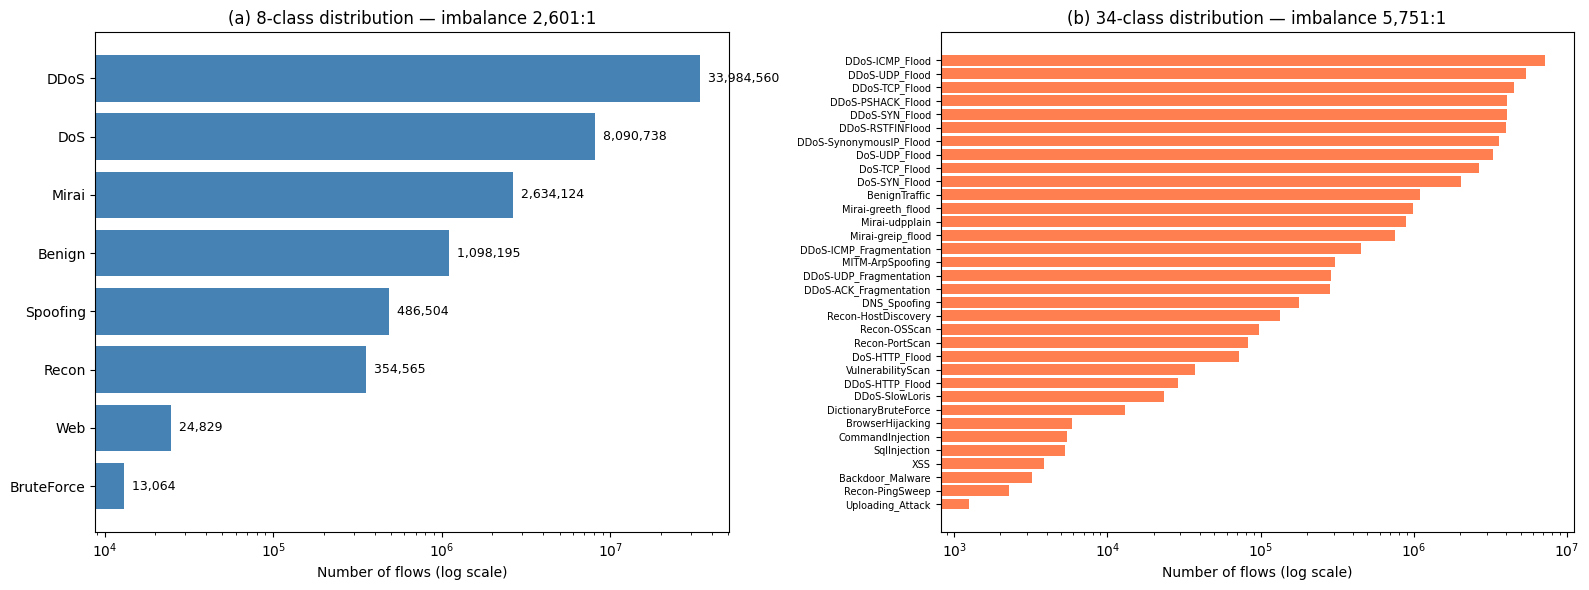

Saved: /home/kali/sae-lof-ids-pi5/data/processed/fig_label_distribution.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) 8-class, log scale
cnts8 = df['label_8'].value_counts().sort_values(ascending=True)
axes[0].barh(cnts8.index.astype(str), cnts8.values, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of flows (log scale)')
axes[0].set_title(f'(a) 8-class distribution — imbalance {cnts8.max()/cnts8.min():,.0f}:1')
for i, v in enumerate(cnts8.values):
    axes[0].text(v, i, f'  {v:,}', va='center', fontsize=9)

# (b) 34-class, log scale
cnts34 = df['label_34'].value_counts().sort_values(ascending=True)
axes[1].barh(cnts34.index.astype(str), cnts34.values, color='coral')
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of flows (log scale)')
axes[1].set_title(f'(b) 34-class distribution — imbalance {cnts34.max()/cnts34.min():,.0f}:1')
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig(DATA_PROC / "fig_label_distribution.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved: {DATA_PROC / 'fig_label_distribution.png'}")

# Quick summary & sanity checks trước khi chuyển sang train SAE

In [15]:
print("="*60)
print("EDA SUMMARY — CIC-IoT2023")
print("="*60)
print(f"Total flows      : {len(df):>14,}")
print(f"Features         : {len(feature_cols)}")
print(f"Benign flows     : {int((df['label_bin']==0).sum()):>14,}  ({100*(df['label_bin']==0).mean():.2f}%)")
print(f"Attack flows     : {int((df['label_bin']==1).sum()):>14,}  ({100*(df['label_bin']==1).mean():.2f}%)")
print(f"Unique labels    : {df[label_col].nunique()} (→ mapped to 8 categories)")
print(f"Imbalance 34-cls : {df['label_34'].value_counts().max() / df['label_34'].value_counts().min():,.0f}:1")
print()
print(f"Train / Val / Test        : {len(idx_train):,} / {len(idx_val):,} / {len(idx_test):,}")
print(f"Benign-train (SAE input)  : {len(idx_train_benign):,}")
print(f"LOF fit sample            : {len(idx_lof):,}")
print()
print(f"Saved artifacts in {DATA_PROC}:")
for p in sorted(DATA_PROC.glob("*")):
    print(f"  {p.name:<30}  {p.stat().st_size/1e6:>8.1f} MB")

print("\n✓ Ready for SAE training (Cell 15+ in next notebook).")

EDA SUMMARY — CIC-IoT2023
Total flows      :     46,686,579
Features         : 46
Benign flows     :      1,098,195  (2.35%)
Attack flows     :     45,588,384  (97.65%)
Unique labels    : 34 (→ mapped to 8 categories)
Imbalance 34-cls : 5,751:1

Train / Val / Test        : 37,349,263 / 4,668,658 / 4,668,658
Benign-train (SAE input)  : 878,556
LOF fit sample            : 100,000

Saved artifacts in /home/kali/sae-lof-ids-pi5/data/processed:
  fig_label_distribution.png           0.1 MB
  label_encoder_34.pkl                 0.0 MB
  label_encoder_8.pkl                  0.0 MB
  lof_fit.parquet                      7.4 MB
  scaler_benign.pkl                    0.0 MB
  split_indices.npz                  197.8 MB
  test.parquet                       182.5 MB
  train.parquet                     1458.8 MB
  train_benign.parquet                53.2 MB
  val.parquet                        182.6 MB

✓ Ready for SAE training (Cell 15+ in next notebook).
